In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Device configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize CartPole
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

### Define the Neural Networks
We define a Policy Network to output action probabilities and a Value Network to act as our baseline.

In [5]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x):
        logits = self.network(x)
        return F.softmax(logits, dim=-1)

class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super(ValueNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.network(x)

### The REINFORCE Update 
LogicThis function handles the collection of returns ($G_t$) and the gradient update. Note the use of .detach() on the advantage to ensure the policy gradient doesn't flow through the baseline.

In [6]:
def update_agent(policy_net, value_net, p_optimizer, v_optimizer, log_probs, rewards, states, gamma, use_baseline=True):
    # 1. Compute Discounted Returns (G_t)
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    log_probs = torch.stack(log_probs)
    states = torch.stack(states)

    if use_baseline:
        # Calculate Advantage: A = G_t - V(s)
        values = value_net(states).squeeze()
        advantage = returns - values.detach() # Detach baseline to stabilize policy gradient
        
        policy_loss = -(log_probs * advantage).mean()
        value_loss = F.mse_loss(values, returns)

        # Update Critic (Baseline)
        v_optimizer.zero_grad()
        value_loss.backward()
        v_optimizer.step()
    else:
        # Vanilla REINFORCE (no baseline)
        policy_loss = -(log_probs * returns).mean()

    # Update Actor (Policy)
    p_optimizer.zero_grad()
    policy_loss.backward()
    p_optimizer.step()

### Training Loop
We run the training across multiple seeds to show the variance reduction requested by the professor.

In [7]:
def train(use_baseline=True, num_episodes=500, seeds=3):
    all_rewards = []
    for seed in range(seeds):
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        # New networks for each seed
        policy_net = PolicyNetwork(state_dim, action_dim).to(device)
        value_net = ValueNetwork(state_dim).to(device)
        p_opt = optim.Adam(policy_net.parameters(), lr=1e-3)
        v_opt = optim.Adam(value_net.parameters(), lr=1e-3)
        
        seed_rewards = []
        for ep in range(num_episodes):
            state, _ = env.reset()
            log_probs, rewards, states = [], [], []
            done = False
            
            while not done:
                state_t = torch.FloatTensor(state).to(device)
                probs = policy_net(state_t)
                dist = Categorical(probs)
                action = dist.sample()
                
                next_state, reward, terminated, truncated, _ = env.step(action.item())
                
                log_probs.append(dist.log_prob(action))
                states.append(state_t)
                rewards.append(reward)
                
                state = next_state
                done = terminated or truncated
            
            # Perform the update
            update_agent(policy_net, value_net, p_opt, v_opt, log_probs, rewards, states, 0.99, use_baseline)
            seed_rewards.append(sum(rewards))
            
        all_rewards.append(seed_rewards)
        print(f"Finished Seed {seed} | Baseline={use_baseline}")
    
    # Checkpoint the trained model
    torch.save(policy_net.state_dict(), f"lab6_model_{'baseline' if use_baseline else 'vanilla'}.pth")
    return np.array(all_rewards)

### Visualizing Mean and Variance
As per the lab requirements, we plot the mean return and the standard deviation (variance) across seeds.

Running Vanilla REINFORCE...
Finished Seed 0 | Baseline=False
Finished Seed 1 | Baseline=False
Finished Seed 2 | Baseline=False

Running REINFORCE with Baseline...
Finished Seed 0 | Baseline=True
Finished Seed 1 | Baseline=True
Finished Seed 2 | Baseline=True


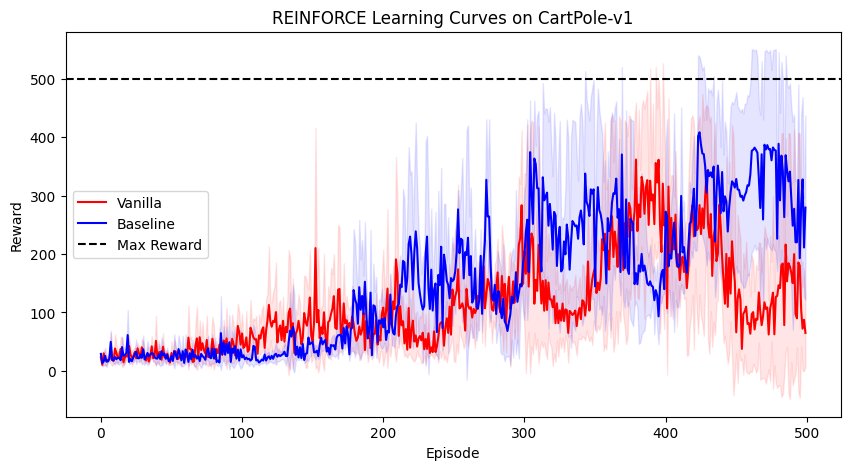

In [8]:
print("Running Vanilla REINFORCE...")
rewards_vanilla = train(use_baseline=False)

print("\nRunning REINFORCE with Baseline...")
rewards_baseline = train(use_baseline=True)

# Plotting the Mean Return and Variance
plt.figure(figsize=(10, 5))
for data, label, color in [(rewards_vanilla, 'Vanilla', 'red'), (rewards_baseline, 'Baseline', 'blue')]:
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    plt.plot(mean, label=label, color=color)
    plt.fill_between(range(len(mean)), mean-std, mean+std, color=color, alpha=0.1)

plt.axhline(y=500, color='black', linestyle='--', label='Max Reward')
plt.title("REINFORCE Learning Curves on CartPole-v1")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()

In [10]:
# You must run this to define policy_net and value_net
policy_net = PolicyNetwork(state_dim, action_dim).to(device)
value_net = ValueNetwork(state_dim).to(device)

In [14]:
# Added 'value_net' to the unpacking line
print("Starting training with baseline...")
policy_net, value_net, rewards_baseline = train(use_baseline=True, num_episodes=500)

print("Training complete. policy_net and value_net are now defined.")

Starting training with baseline...
Finished Seed 0 | Baseline=True
Finished Seed 1 | Baseline=True
Finished Seed 2 | Baseline=True
Training complete. policy_net and value_net are now defined.


In [17]:
# The underscore _ tells Python to ignore the middle value (the value network)
policy_net, _, rewards_baseline = train(use_baseline=True, num_episodes=500)

Finished Seed 0 | Baseline=True
Finished Seed 1 | Baseline=True
Finished Seed 2 | Baseline=True


In [ ]:
# Unpack with rewards first
rewards_baseline, policy_net, value_net = train(use_baseline=True, num_episodes=500)

# Check the types to be sure
print(f"Type of rewards: {type(rewards_baseline)}") # Expect <class 'numpy.ndarray'>
print(f"Type of policy: {type(policy_net)}")       # Expect <class '__main__.PolicyNetwork'>

# Now save
torch.save(policy_net.state_dict(), 'models/reinforce_policy.pth')